In [1]:
from pytrends.request import TrendReq
import pandas as pd

In [2]:
# connect to google trends
pytrends = TrendReq(hl = 'en-US' , tz = 330)

In [3]:

# keywords
keywords = ["ChatGPT" , "Bitcoin", "World Cup"]

In [4]:
# fetch data
pytrends.build_payload(keywords , timeframe = 'today 12-m')
data = pytrends.interest_over_time()

In [5]:
# clean
data = data.drop(columns = ['isPartial'])

In [6]:

print(data.head())

            ChatGPT  Bitcoin  World Cup
date                                   
2025-07-06       19        2          3
2025-07-13       20        2          2
2025-07-20       21        2          1
2025-07-27       21        2          1
2025-08-03       23        2          1


In [7]:
#save dataset
data.to_csv("trends.csv")

In [8]:
import pandas as pd

data = pd.read_csv("trends.csv" , index_col = 0)
data.index = pd.to_datetime(data.index)

print(data.head())

            ChatGPT  Bitcoin  World Cup
date                                   
2025-07-06       19        2          3
2025-07-13       20        2          2
2025-07-20       21        2          1
2025-07-27       21        2          1
2025-08-03       23        2          1


In [9]:
data_smooth = data.rolling(window = 7).mean()

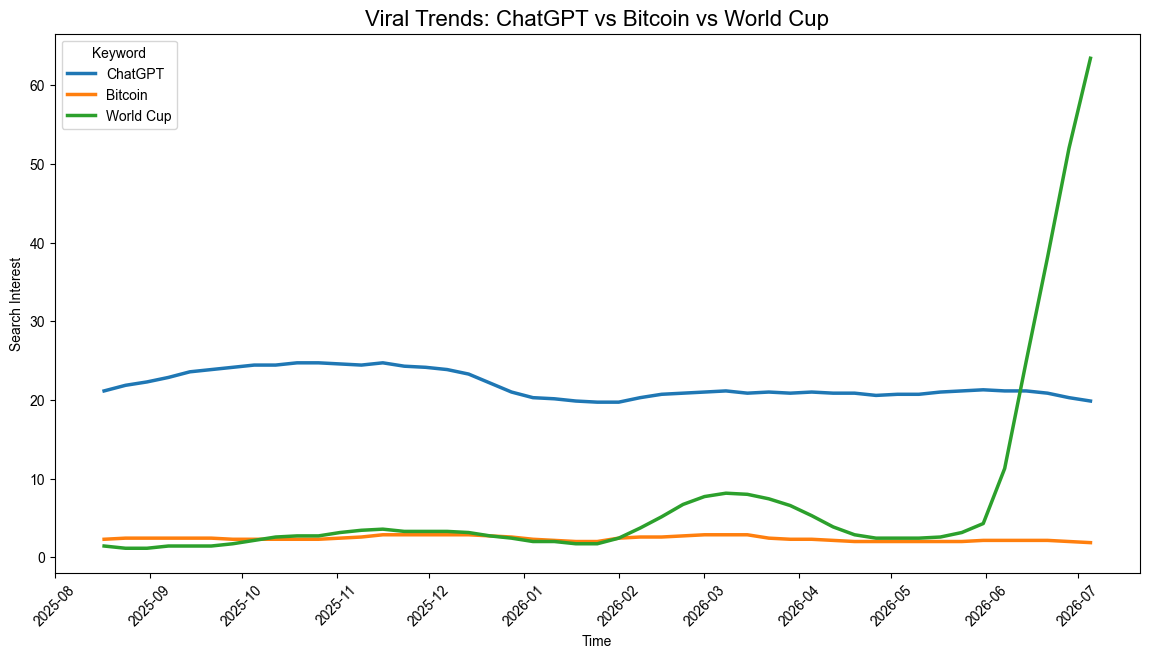

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# reset index so date becomes a column
df = data_smooth.reset_index()
#convert wide -> long
df_long = df.melt(id_vars='date' , var_name = 'Keyword' , value_name='Interest')

plt.figure(figsize=(14,7))

sns.lineplot(data=df_long , x = 'date' , y = 'Interest' , hue = 'Keyword' , linewidth = 2.5)

plt.title("Viral Trends: ChatGPT vs Bitcoin vs World Cup", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)

sns.set_style("whitegrid")

plt.show()

In [14]:
avg_values = data_smooth.mean()
print(avg_values)

ChatGPT      21.878419
Bitcoin       2.367781
World Cup     7.030395
dtype: float64


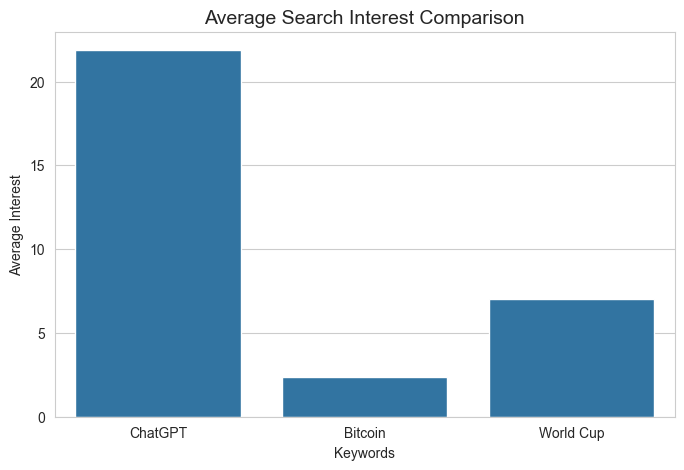

In [16]:
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_values.index,
    y=avg_values.values
)

plt.title("Average Search Interest Comparison", fontsize=14)
plt.xlabel("Keywords")
plt.ylabel("Average Interest")

plt.show()

In [17]:
corr = data_smooth.corr()
print(corr)

            ChatGPT   Bitcoin  World Cup
ChatGPT    1.000000  0.427332  -0.297900
Bitcoin    0.427332  1.000000  -0.301988
World Cup -0.297900 -0.301988   1.000000


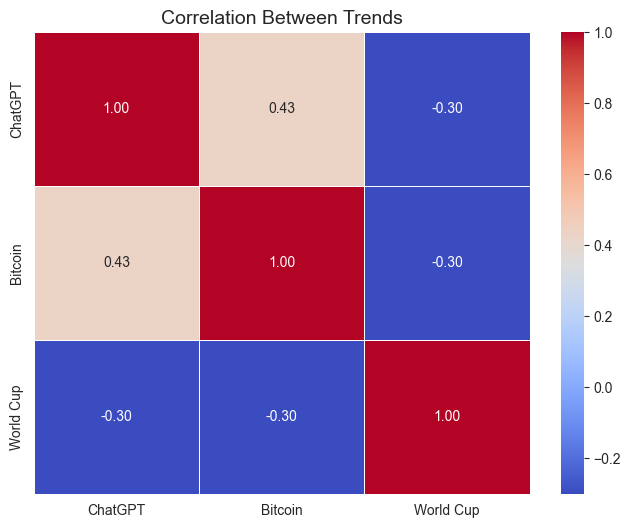

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,          
    cmap="coolwarm",     
    fmt=".2f",           
    linewidths=0.5
)

plt.title("Correlation Between Trends", fontsize=14)

plt.show()

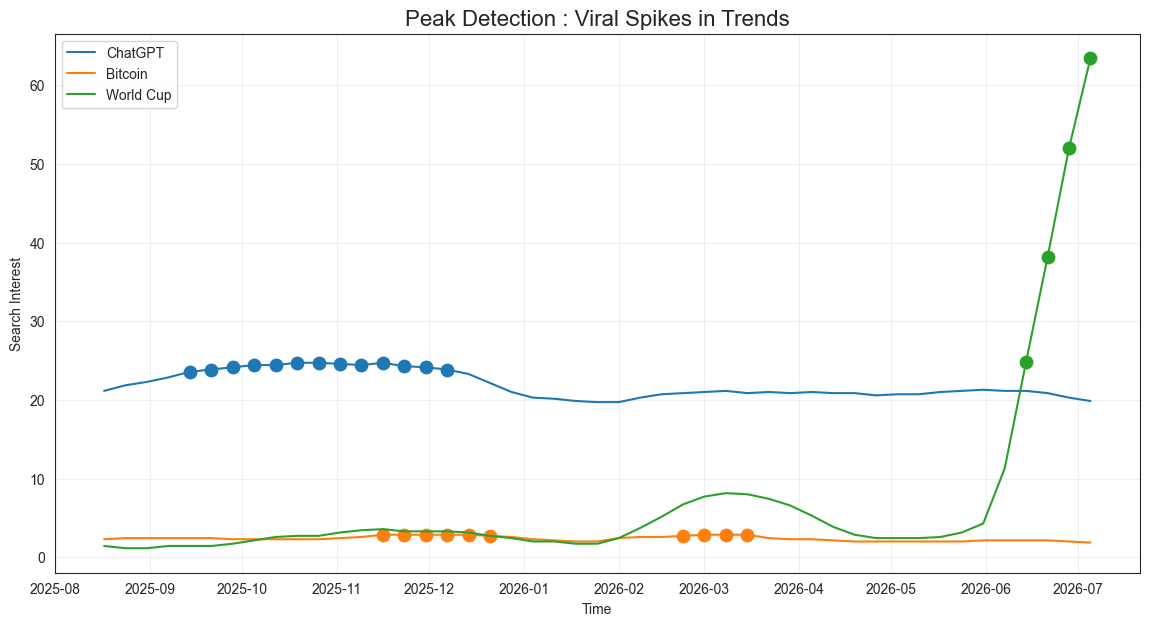

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14,7))

for col in data_smooth.columns:
    #plot normal line
    plt.plot(data_smooth.index , data_smooth[col] , label = col)

    #detect peaks (simple threshold method)
    threshold = data_smooth[col].mean() + data_smooth[col].std()

    peaks = data_smooth[data_smooth[col] > threshold]

    #mark peaks
    plt.scatter(peaks.index , peaks[col] , s = 80 , marker ='o')

plt.title("Peak Detection : Viral Spikes in Trends" , fontsize = 16)
plt.xlabel("Time") 
plt.ylabel("Search Interest")
plt.legend()
plt.grid(alpha=0.3)

plt.show() 


In [38]:
print(data_smooth.isna().sum())

ChatGPT      0
Bitcoin      0
World Cup    0
dtype: int64


In [39]:
data_smooth = data_smooth.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = data_smooth.T

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2 , random_state=42)
clusters = kmeans.fit_predict(X_scaled)

for i,keyword in enumerate(X.index):
    print(keyword, "-> Cluster", clusters[i])

ChatGPT -> Cluster 1
Bitcoin -> Cluster 0
World Cup -> Cluster 0


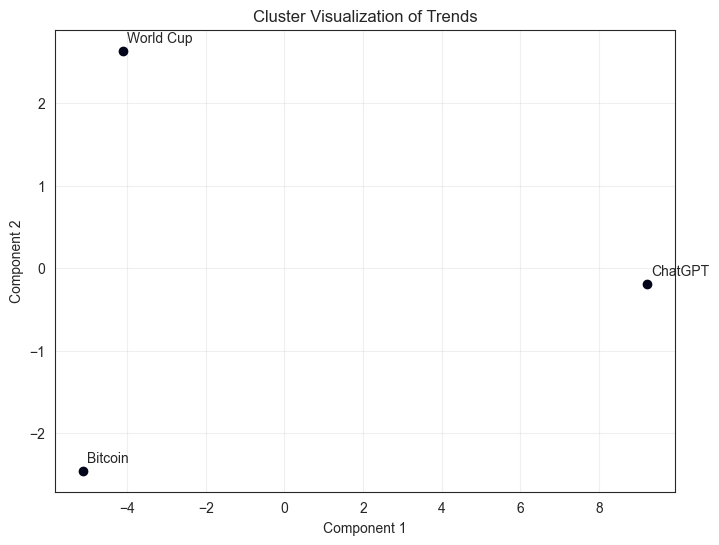

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize = (8,6))

for i,keyword in enumerate(X.index):
    plt.scatter(X_pca[i,0] , X_pca[i,1] , c = clusters[i])
    plt.text(X_pca[i,0]+0.1 , X_pca[i,1]+0.1 , keyword)

plt.title("Cluster Visualization of Trends")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.3)

plt.show()

In [46]:
volatility = data_smooth.std()
print(volatility)

ChatGPT       7.172031
Bitcoin       0.808891
World Cup    12.004516
dtype: float64


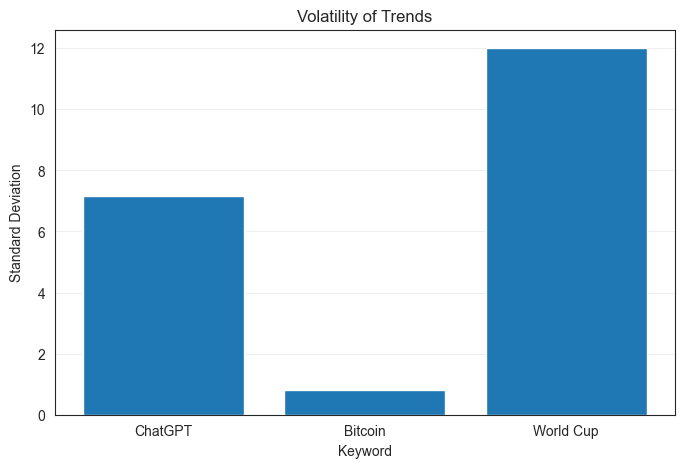

In [47]:
import matplotlib.pyplot as plt
volatility = data_smooth.std()

plt.figure(figsize=(8,5))
plt.bar(volatility.index , volatility.values)

plt.title("Volatility of Trends")
plt.xlabel("Keyword")
plt.ylabel("Standard Deviation")
plt.grid(axis = 'y' , alpha = 0.3)

plt.show()